# SIFT Feature Extraction

This part extracts SIFT keypoints and descriptors from images.

Unlike HOG and colour histograms, the number of SIFT keypoints can be different for each image. Each detected keypoint produces one 128-value descriptor.

## 1. Import libraries

Import the libraries needed for image loading, SIFT extraction, data handling, and visualisation.

In [37]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

## 2. Load the shared project configuration

Find the project root and load the shared settings from `src/config.py`.

In [38]:
current_path = Path.cwd().resolve()

for parent in [current_path, *current_path.parents]:
    if (parent / "src" / "config.py").exists():
        project_root = parent
        break
else:
    raise FileNotFoundError(
        "Could not find the project root containing src/config.py"
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import config

print("Project root:", project_root)
print("Image size:", config.IMG_SIZE)
print("Training CSV:", config.TRAIN_CSV)

Project root: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group
Image size: (224, 224)
Training CSV: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\data\processed\train.csv


## 3. Load and check a sample image

Select one image from the training set, check the image path, and display its basic information.

Dataset size: 20000
Sample index: 0
Image path: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\data\raw\train_mini\07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii\f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg
Original size: (281, 500)
Image mode: RGB
Label: 364
Category: Xylorhiza orcuttii


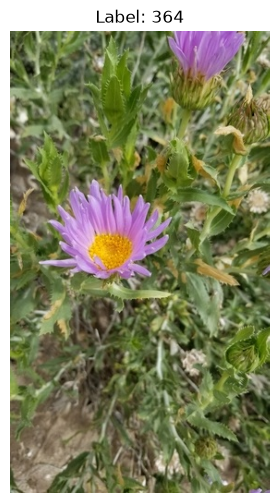

In [39]:
train_df = pd.read_csv(config.TRAIN_CSV)

required_columns = {"file_path", "label"}
missing_columns = required_columns - set(train_df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required CSV columns: {sorted(missing_columns)}"
    )

if train_df.empty:
    raise ValueError("The training CSV is empty.")

sample_index = 0

if sample_index < 0 or sample_index >= len(train_df):
    raise IndexError(
        f"sample_index must be between 0 and {len(train_df) - 1}"
    )

sample_row = train_df.iloc[sample_index]
sample_path = (
    Path(config.DATA_RAW_ROOT)
    / str(sample_row["file_path"])
)

if not sample_path.exists():
    raise FileNotFoundError(
        f"Sample image was not found: {sample_path}"
    )

with Image.open(sample_path) as image:
    sample_image = image.convert("RGB")

print("Dataset size:", len(train_df))
print("Sample index:", sample_index)
print("Image path:", sample_path)
print("Original size:", sample_image.size)
print("Image mode:", sample_image.mode)
print("Label:", sample_row["label"])

if "category_name" in train_df.columns:
    print("Category:", sample_row["category_name"])

plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"Label: {sample_row['label']}")
plt.show()

## 4. Define the SIFT feature function

Resizes the image, converts it to grayscale, and extracts SIFT keypoints and descriptors.

`max_features=500` requests approximately 500 of the strongest keypoints.

The returned number may be slightly different because SIFT can create multiple keypoints with different orientations at the same location.

In [40]:
def extract_sift_feature(image, max_features=500):
    if not isinstance(image, Image.Image):
        raise TypeError(
            "image must be a PIL.Image.Image object."
        )

    if not isinstance(max_features, int) or max_features <= 0:
        raise ValueError(
            "max_features must be a positive integer."
        )

    resized_image = image.convert("RGB").resize(
        config.IMG_SIZE
    )

    image_array = np.asarray(resized_image)

    gray_image = cv2.cvtColor(
        image_array,
        cv2.COLOR_RGB2GRAY
    )

    sift = cv2.SIFT_create(
        nfeatures=max_features
    )

    keypoints, descriptors = sift.detectAndCompute(
        gray_image,
        None
    )

    if descriptors is None:
        descriptors = np.empty(
            (0, 128),
            dtype=np.float32
        )
    else:
        descriptors = descriptors.astype(
            np.float32
        )

    return keypoints, descriptors

## 5. Test the SIFT feature

Extract SIFT keypoints and descriptors from the sample image and check the output.

In [41]:
keypoints, descriptors = extract_sift_feature(
    sample_image,
    max_features=500
)

print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)
print("Descriptor dtype:", descriptors.dtype)
print("Contains NaN:", np.isnan(descriptors).any())
print("Contains infinity:", np.isinf(descriptors).any())

Number of keypoints: 500
Descriptor shape: (500, 128)
Descriptor dtype: float32
Contains NaN: False
Contains infinity: False


## 6. Visualise the SIFT keypoints

Draw the detected SIFT keypoints on the resized sample image.

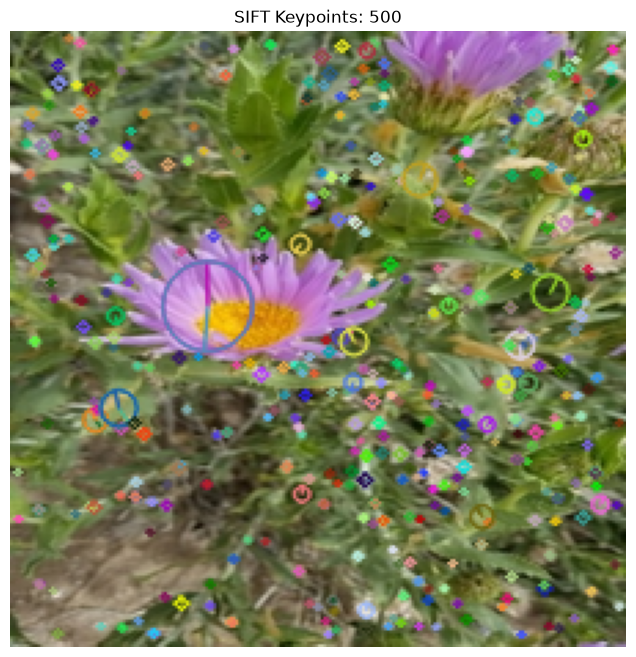

In [42]:
resized_sample = sample_image.resize(
    config.IMG_SIZE
)

sample_array = np.asarray(
    resized_sample
)

keypoint_image = cv2.drawKeypoints(
    sample_array,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(8, 8))
plt.imshow(keypoint_image)
plt.axis("off")
plt.title(f"SIFT Keypoints: {len(keypoints)}")
plt.show()

## 7. Check the descriptor values

Check the value range and basic statistics of the SIFT descriptors.

In [43]:
if len(descriptors) > 0:
    print("Minimum value:", descriptors.min())
    print("Maximum value:", descriptors.max())
    print("Mean value:", descriptors.mean())
    print("Standard deviation:", descriptors.std())
    print("First descriptor shape:", descriptors[0].shape)
else:
    print("No SIFT descriptors were found.")

Minimum value: 0.0
Maximum value: 180.0
Mean value: 28.957485
Standard deviation: 34.7787
First descriptor shape: (128,)


## 8. Visualise one SIFT descriptor

Display the 128 values of the first SIFT descriptor.

Each descriptor describes the local gradient information around one detected keypoint.

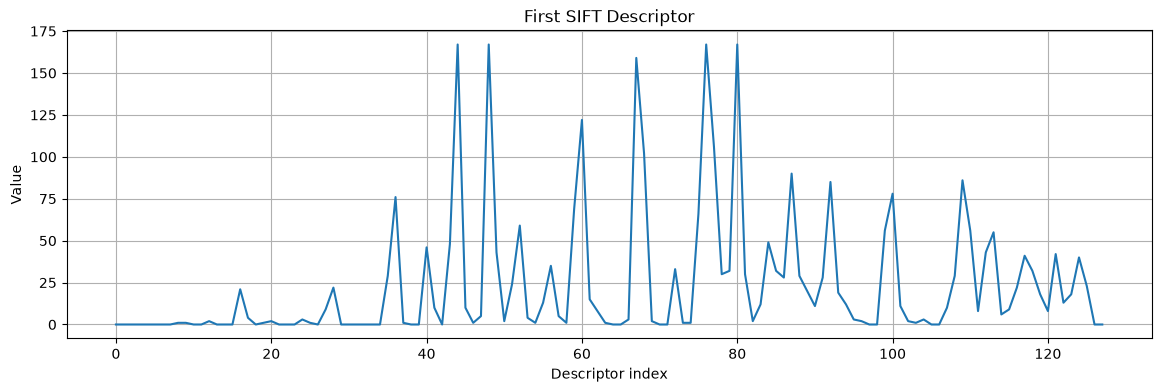

In [44]:
if len(descriptors) > 0:
    plt.figure(figsize=(14, 4))
    plt.plot(descriptors[0])
    plt.xlabel("Descriptor index")
    plt.ylabel("Value")
    plt.title("First SIFT Descriptor")
    plt.grid(True)
    plt.show()
else:
    print("No SIFT descriptor is available to display.")

## 9. Test images from different classes

Test the SIFT feature extractor on images from different labels.

The number of descriptors may change between images, but every descriptor must contain 128 values.

In [45]:
test_rows = (
    train_df
    .drop_duplicates(subset="label")
    .head(5)
)

test_results = []

for _, row in test_rows.iterrows():
    image_path = (
        Path(config.DATA_RAW_ROOT)
        / str(row["file_path"])
    )

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image was not found: {image_path}"
        )

    with Image.open(image_path) as image:
        test_image = image.convert("RGB")

    test_keypoints, test_descriptors = (
        extract_sift_feature(
            test_image,
            max_features=500
        )
    )

    category = (
        row["category_name"]
        if "category_name" in train_df.columns
        else "N/A"
    )

    result = {
        "label": row["label"],
        "category": category,
        "keypoints": len(test_keypoints),
        "descriptor_shape": test_descriptors.shape,
        "dtype": str(test_descriptors.dtype),
        "finite": np.isfinite(
            test_descriptors
        ).all()
    }

    test_results.append(result)

    print(
        f"Label: {result['label']}, "
        f"Category: {result['category']}, "
        f"Keypoints: {result['keypoints']}, "
        f"Descriptor shape: "
        f"{result['descriptor_shape']}, "
        f"Dtype: {result['dtype']}, "
        f"Finite: {result['finite']}"
    )

Label: 364, Category: Xylorhiza orcuttii, Keypoints: 500, Descriptor shape: (500, 128), Dtype: float32, Finite: True
Label: 251, Category: Sceloporus orcutti, Keypoints: 501, Descriptor shape: (501, 128), Dtype: float32, Finite: True
Label: 449, Category: Malvaviscus arboreus, Keypoints: 500, Descriptor shape: (500, 128), Dtype: float32, Finite: True
Label: 404, Category: Lysimachia clethroides, Keypoints: 500, Descriptor shape: (500, 128), Dtype: float32, Finite: True
Label: 199, Category: Pycnonotus leucotis, Keypoints: 500, Descriptor shape: (500, 128), Dtype: float32, Finite: True


## 10. Display the test results

It places the SIFT test results into a table for easier comparison.

In [46]:
results_df = pd.DataFrame(
    test_results
)

results_df

,label,category,keypoints,descriptor_shape,dtype,finite
0,364,Xylorhiza orcuttii,500,"(500, 128)",float32,True
1,251,Sceloporus orcutti,501,"(501, 128)",float32,True
2,449,Malvaviscus arboreus,500,"(500, 128)",float32,True
3,404,Lysimachia clethroides,500,"(500, 128)",float32,True
4,199,Pycnonotus leucotis,500,"(500, 128)",float32,True


##  11. Visualise keypoints from different classes

Display the detected SIFT keypoints for the selected images from different classes.

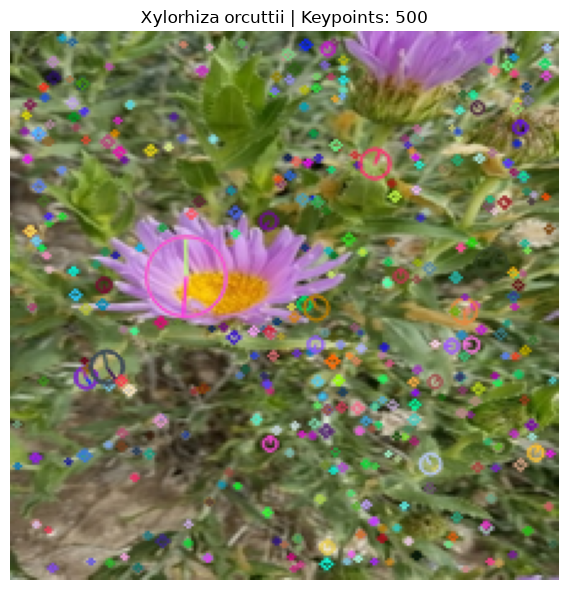

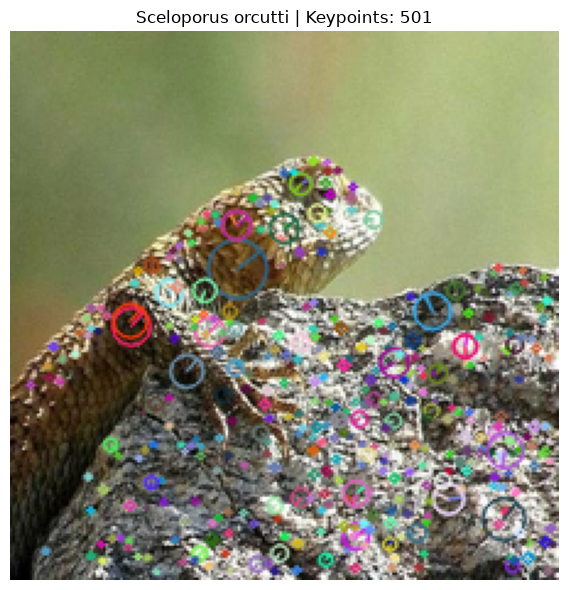

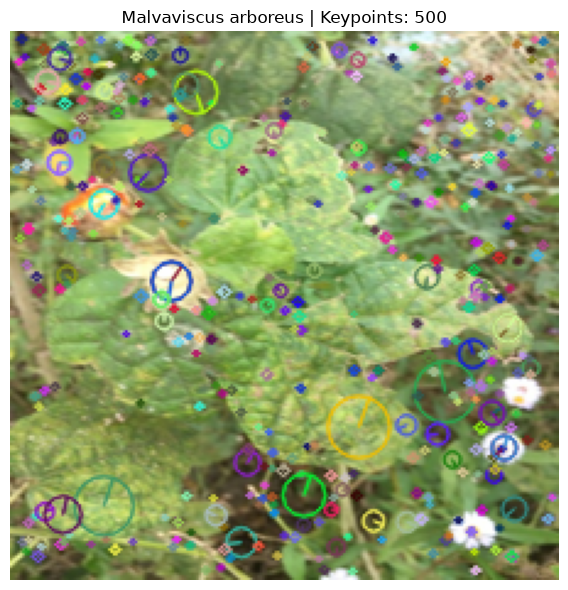

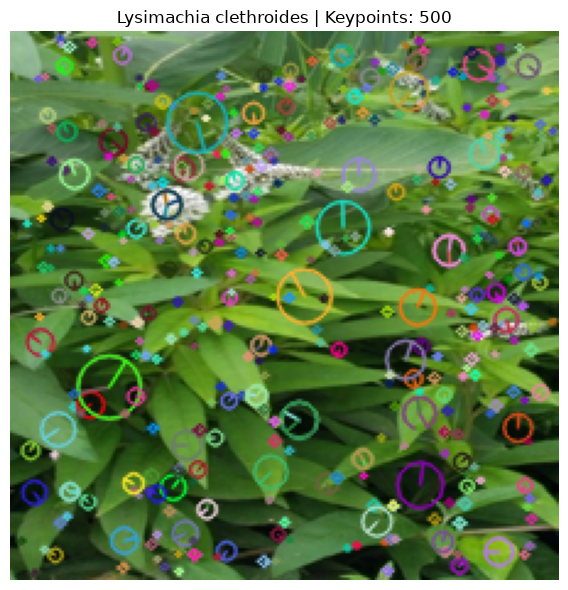

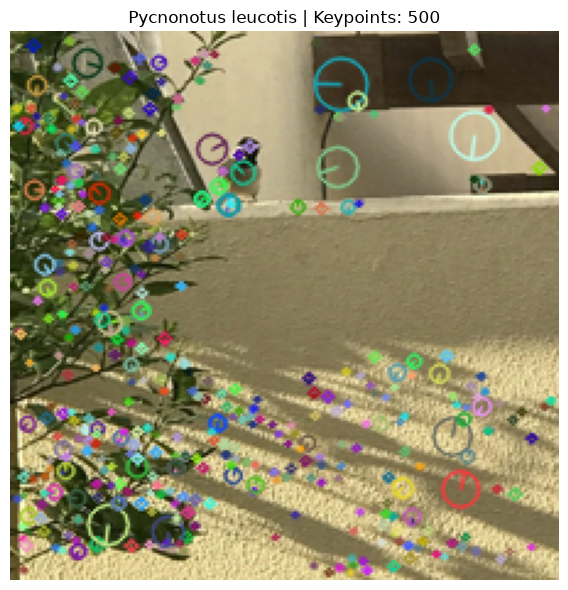

In [51]:
for _, row in test_rows.iterrows():
    image_path = (
        Path(config.DATA_RAW_ROOT)
        / str(row["file_path"])
    )

    with Image.open(image_path) as image:
        test_image = image.convert("RGB")

    test_keypoints, _ = extract_sift_feature(
        test_image,
        max_features=500
    )

    resized_image = test_image.resize(
        config.IMG_SIZE
    )

    image_array = np.asarray(
        resized_image
    )

    keypoint_image = cv2.drawKeypoints(
        image_array,
        test_keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    category = (
        row["category_name"]
        if "category_name" in train_df.columns
        else f"Label {row['label']}"
    )

    plt.figure(figsize=(7, 6))
    plt.imshow(keypoint_image)
    plt.axis("off")

    plt.title(
        f"{category} | "
        f"Keypoints: {len(test_keypoints)}"
    )

    plt.tight_layout()
    plt.show()

## 12. Check the descriptor dimensions

Confirm that all tested SIFT descriptors contain 128 values.

In [48]:
descriptor_dimensions = [
    result["descriptor_shape"][1]
    for result in test_results
]

print(
    "Descriptor dimensions:",
    descriptor_dimensions
)

print(
    "All descriptors have 128 values:",
    all(
        dimension == 128
        for dimension in descriptor_dimensions
    )
)

Descriptor dimensions: [128, 128, 128, 128, 128]
All descriptors have 128 values: True


## 13. Check whether the number of descriptors is fixed

SIFT detects a different number of keypoints in different images.

Compare the descriptor row counts produced by the tested images.

In [49]:
keypoint_counts = [
    result["keypoints"]
    for result in test_results
]

print("Keypoint counts:", keypoint_counts)

print(
    "Same number of keypoints:",
    len(set(keypoint_counts)) == 1
)

Keypoint counts: [500, 501, 500, 500, 500]
Same number of keypoints: False


## 14. Final validation

Perform the final checks for the sample SIFT output.

The number of descriptor rows may vary between images, but every descriptor must contain 128 values.

In [50]:
validation_checks = {
    "Descriptor is two-dimensional":
        descriptors.ndim == 2,

    "Each descriptor has 128 values":
        descriptors.shape[1] == 128,

    "Descriptor dtype is float32":
        descriptors.dtype == np.float32,

    "All descriptor values are finite":
        np.isfinite(descriptors).all(),

    "Keypoint count matches descriptor rows":
        len(keypoints) == descriptors.shape[0]
}

for check_name, passed in validation_checks.items():
    print(f"{check_name}: {passed}")

print(
    "\nAll checks passed:",
    all(validation_checks.values())
)

Descriptor is two-dimensional: True
Each descriptor has 128 values: True
Descriptor dtype is float32: True
All descriptor values are finite: True
Keypoint count matches descriptor rows: True

All checks passed: True


## Summary

SIFT was used to detect local keypoints and extract 128-dimensional descriptors.

Different images produced different numbers of descriptors, so the raw SIFT output does not have a fixed length. Because of this, it cannot be directly added to the current HOG and colour feature vector.

A method such as Bag of Visual Words would be needed before using SIFT with the traditional classifiers.